In [36]:
# Just copy and past output

import os
import subprocess

def dump_compile_commands(rootdir):
  for dirpath, dirnames, filenames in os.walk(rootdir):
    for file in filenames: 
      if file == "test.s":
        path = os.path.join(dirpath, file).replace("\\", "/")
        testname = dirpath.split("\\")[-1]
        command = f'mipsel-linux-gnu-gcc -mips32 {path} -nostartfiles -Ttext=0 -o compiled-tests/{testname}-test'
        print(command)
      # subprocess.call(command, shell=True, capture_output=True, text=True)

In [92]:
def dump_test_logs():
  for dirpath, dirnames, filenames in os.walk("compiled-tests"):
    for file in filenames:
      test_path = os.path.join(dirpath, file).replace("\\", "/")
      logname = file.rsplit("-test", maxsplit=1)[0]
      command = f'./processor --bmk={test_path} -O2 > test-logs/{logname}-log'
      print(command)
dump_test_logs()

./processor --bmk=compiled-tests/Customize-branch_prediction_1-test -O2 > test-logs/Customize-branch_prediction_1-log
./processor --bmk=compiled-tests/Customize-branch_prediction_2-test -O2 > test-logs/Customize-branch_prediction_2-log
./processor --bmk=compiled-tests/Customize-branch_prediction_3-test -O2 > test-logs/Customize-branch_prediction_3-log
./processor --bmk=compiled-tests/Customize-instruction_prefetch_1-test -O2 > test-logs/Customize-instruction_prefetch_1-log
./processor --bmk=compiled-tests/Customize-instruction_prefetch_2-test -O2 > test-logs/Customize-instruction_prefetch_2-log
./processor --bmk=compiled-tests/Customize-memory_bound_L1-test -O2 > test-logs/Customize-memory_bound_L1-log
./processor --bmk=compiled-tests/Customize-memory_bound_L2-test -O2 > test-logs/Customize-memory_bound_L2-log
./processor --bmk=compiled-tests/Customize-memory_bound_memory-test -O2 > test-logs/Customize-memory_bound_memory-log
./processor --bmk=compiled-tests/Customize-memory_random-tes

In [37]:
dump_compile_commands('test_data_customize')

mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-branch_prediction_1/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-branch_prediction_1-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-branch_prediction_2/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-branch_prediction_2-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-branch_prediction_3/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-branch_prediction_3-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-instruction_prefetch_1/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-instruction_prefetch_1-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-instruction_prefetch_2/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-instruction_prefetch_2-test
mipsel-linux-gnu-gcc -mips32 test_data_customize/Customize-memory_bound_L1/test.s -nostartfiles -Ttext=0 -o compiled-tests/Customize-memory_bound_L1-test
mipsel-linux-gnu-gcc -mi

In [38]:
dump_compile_commands('test_data_pipeline')

mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-branch/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-branch-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-dependent_stores/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-dependent_stores-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-false_dependency/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-false_dependency-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-forward_to_rs/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-forward_to_rs-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-forward_to_rt/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-forward_to_rt-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-hidden/test.s -nostartfiles -Ttext=0 -o compiled-tests/MIPSPipeline-hidden-test
mipsel-linux-gnu-gcc -mips32 test_data_pipeline/MIPSPipeline-load_use/test.s -nostartf

In [95]:
OBSERVED_CYCLE_COUNTS = {}

def dump_cycle_counts():
  for dirpath, dirnames, filenames in os.walk("test-logs"):
    for fname in filenames:
      log_path = os.path.join(dirpath, fname).replace("\\", "/")
      testname = fname.split("-log")[0]
      with open(log_path) as file:
        test_cycle_count = int(file.readlines()[-35].split(" ")[-1])
        OBSERVED_CYCLE_COUNTS[testname] = test_cycle_count

dump_cycle_counts()
print(OBSERVED_CYCLE_COUNTS)
print(len(OBSERVED_CYCLE_COUNTS))


{'Customize-branch_prediction_1': 1050, 'Customize-branch_prediction_2': 1107, 'Customize-branch_prediction_3': 2318, 'Customize-instruction_prefetch_1': 391, 'Customize-instruction_prefetch_2': 653, 'Customize-memory_bound_L1': 3855, 'Customize-memory_bound_L2': 2641, 'Customize-memory_bound_memory': 13681, 'Customize-memory_random': 58019, 'Customize-store_to_load_1': 178, 'Customize-store_to_load_2': 326, 'Customize-superscalar_R10000': 642, 'Customize-unified_cache_1': 78, 'Customize-value_prediction': 844, 'Customize-victim_cache': 3825, 'MIPSPipeline-branch': 137, 'MIPSPipeline-dependent_stores': 118, 'MIPSPipeline-false_dependency': 78, 'MIPSPipeline-forward_to_rs': 78, 'MIPSPipeline-forward_to_rt': 79, 'MIPSPipeline-hidden': 216, 'MIPSPipeline-load_use': 145, 'MIPSPipeline-raw_dependency': 78, 'MIPSPipeline-reg_file_fowarding': 70, 'MIPSPipeline-simple_no_branch_no_dep': 154, 'SpeculativeMIPS-3bit_011': 334, 'SpeculativeMIPS-3bit_100': 314, 'SpeculativeMIPS-3bit_double': 384, '

In [110]:
BASE_CYCLE_COUNTS = {
  "Customize-branch_prediction_1": 1532,
  "Customize-branch_prediction_2": 1564,
  "Customize-branch_prediction_3": 3310,
  "Customize-instruction_prefetch_1": 392,
  "Customize-instruction_prefetch_2": 652,
  "Customize-memory_bound_L1": 4986,
  "Customize-memory_bound_L2": 4196,
  "Customize-memory_bound_memory": 21988,
  # "Customize-memory_random": None ,
  "Customize-store_to_load_1": 202,
  "Customize-store_to_load_2": 394,
  "Customize-superscalar_R10000": 765,
  # "Customize-unified_cache_1": 77,
  "Customize-value_prediction": 1275,
  "Customize-victim_cache": 6128,
  # "MIPSPipeline-bran  ch": 137,
  "MIPSPipeline-dependent_stores": 141,
  # "MIPSPipeline-false_dependency": 77,
  # "MIPSPipeline-forward_to_rs": 77,
  # "MIPSPipeline-forward_to_rt": 78  ,
  "MIPSPipeline-hidden": 263,
  "MIPSPipeline-load_use": 149,
  # "MIPSPipeline-raw_dependency": 77,
  # "MIPSPipeline-reg_file_fowarding": 69,
  # "MIPSPipeline-simple_no_br  anch_no_dep": 153,
  "SpeculativeMIPS-3bit_011": 389,
  "SpeculativeMIPS-3bit_100": 381,
  "SpeculativeMIPS-3bit_double": 509,
  "SpeculativeMIPS-hidden": 16068,
  "SpeculativeMIPS-one_backward_beq": 3073,
  "SpeculativeMIPS-one_backward_bne": 2568,
  "SpeculativeMIPS-one_forward_beq": 3574,
  "SpeculativeMIPS-one_forward_bne": 4082, 
  "SpeculativeMIPS-static_branch": 389,
  "SpeculativeMIPS-test_case_local": 4069
}


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


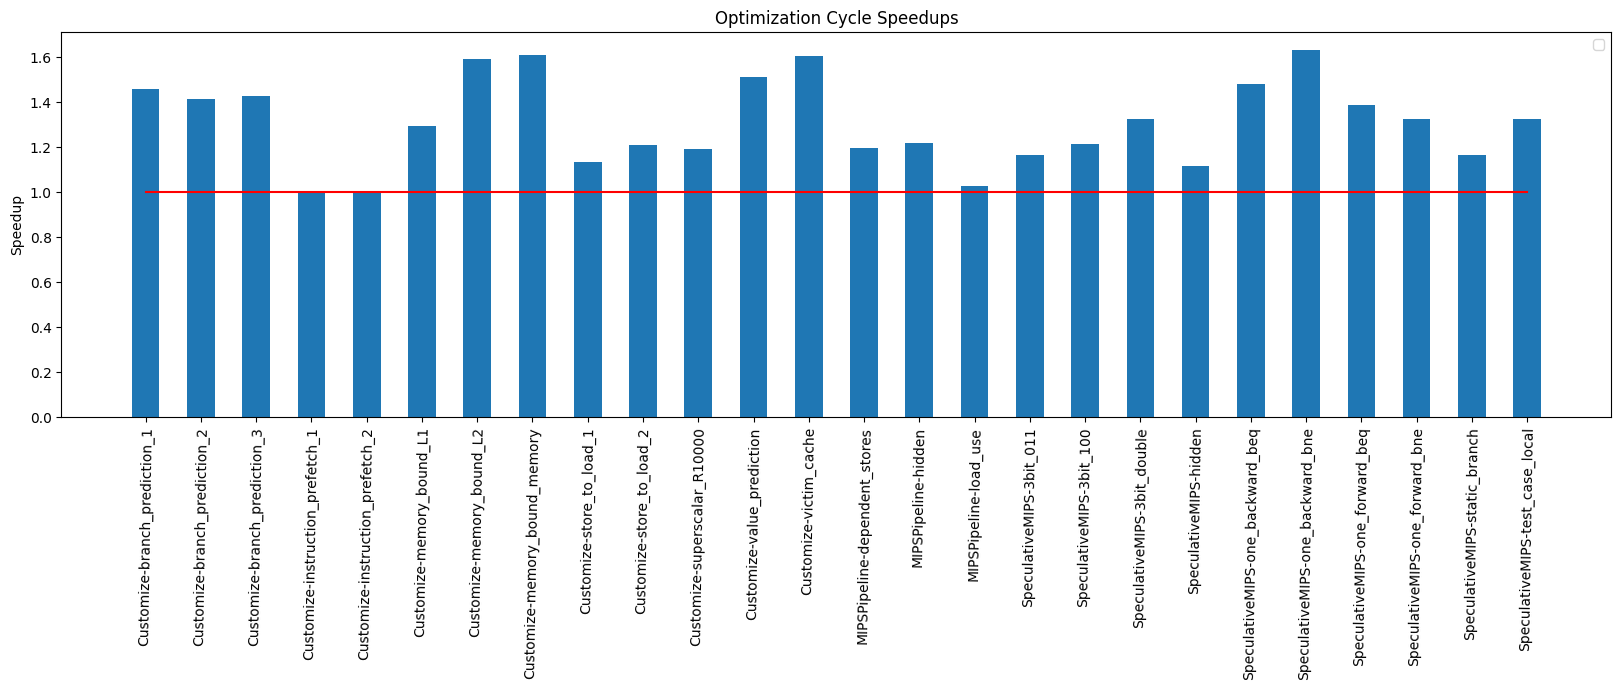

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
tests = BASE_CYCLE_COUNTS.keys()
base_cycles = [BASE_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]
optimized_cycles = [OBSERVED_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]
speedup = [BASE_CYCLE_COUNTS[testname]/OBSERVED_CYCLE_COUNTS[testname] for testname in BASE_CYCLE_COUNTS.keys()]
line_values = [1]* len(tests)

# Setting the positions and width for the bars
pos = np.arange(len(tests))
width = 0.5

# Creating the bars
# plt.bar(pos - width/2, base_cycles, width, label='Base Cycles')
# plt.bar(pos + width/2, optimized_cycles, width, label='Optimized Cycles')
plt.figure(figsize=(20, 5))

plt.bar(tests, speedup, width)

plt.plot(tests, line_values, color='red')

# Adding labels and title
plt.xticks(pos, tests, rotation=89)
plt.ylabel('Speedup')
plt.title('Optimization Cycle Speedups')

# Adding legend
plt.legend()

# Display the graph
plt.show()